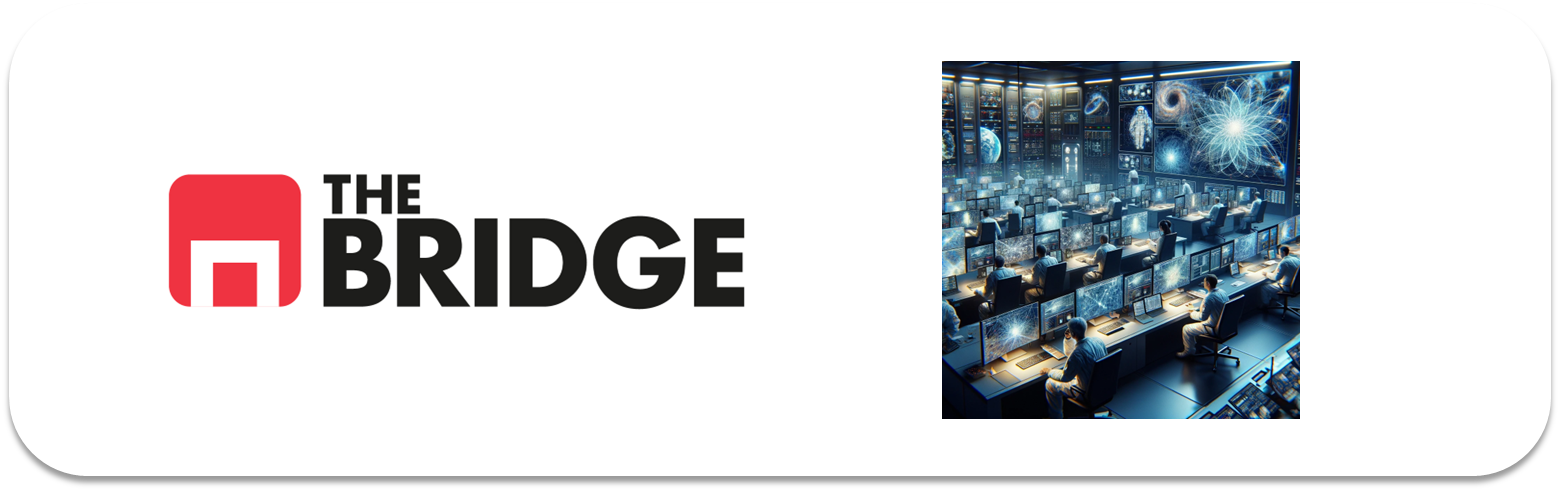

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [4]:
import os

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import shuffle

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import bootcampviztools as bt

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### Ejercicio 1: Carga de las imágenes

Leemos las imágenes de los cuatro directorios de train y del directorio de test, redimensionándolas a 32x32 según se van leyendo. La clase (`cat`/`dog`) va en el propio nombre del fichero (p.ej. `cat.1000.jpg`), así que la sacamos con un simple `split`.

In [5]:
ROOT_PATH = "data/"
TRAIN_DIRS = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]
TEST_DIR = "github_test"
IMG_SIZE = (32, 32)
CLASS_NAMES = ["cat", "dog"]


def read_images(directorio, reshape_dim=(32, 32)):
    """Lee todas las imágenes de un directorio, las redimensiona y saca la clase del nombre del fichero."""
    X = []
    y = []
    for file in os.listdir(directorio):
        label = file.split(".")[0]  # "cat.1000.jpg" -> "cat"
        image = cv2.imread(os.path.join(directorio, file))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # cv2 lee en BGR, lo pasamos a RGB para visualizar bien
        image = cv2.resize(image, reshape_dim)
        X.append(image)
        y.append(label)
    return np.array(X), np.array(y)


X_train_parts, y_train_parts = [], []
for train_dir in TRAIN_DIRS:
    X_dir, y_dir = read_images(os.path.join(ROOT_PATH, train_dir), IMG_SIZE)
    X_train_parts.append(X_dir)
    y_train_parts.append(y_dir)

X_train = np.concatenate(X_train_parts)
y_train_names = np.concatenate(y_train_parts)

# Los directorios van uno de cada clase detrás de otro (cat, cat, dog, dog), así que
# barajamos ya para que cualquier validation_split posterior (Keras/ImageDataGenerator)
# no se quede con un trozo de una sola clase.
X_train, y_train_names = shuffle(X_train, y_train_names, random_state=42)

X_test, y_test_names = read_images(os.path.join(ROOT_PATH, TEST_DIR), IMG_SIZE)

print("X_train:", X_train.shape, "y_train:", y_train_names.shape)
print("X_test:", X_test.shape, "y_test:", y_test_names.shape)

X_train: (4000, 32, 32, 3) y_train: (4000,)
X_test: (1000, 32, 32, 3) y_test: (1000,)


### Ejercicio 2: Visualización, MiniEDA y construcción del modelo

#### Visualización del dataset

Como siempre que trabajamos con imágenes, lo primero es echar un vistazo a una muestra para comprobar que hemos cargado bien los datos y sus etiquetas.

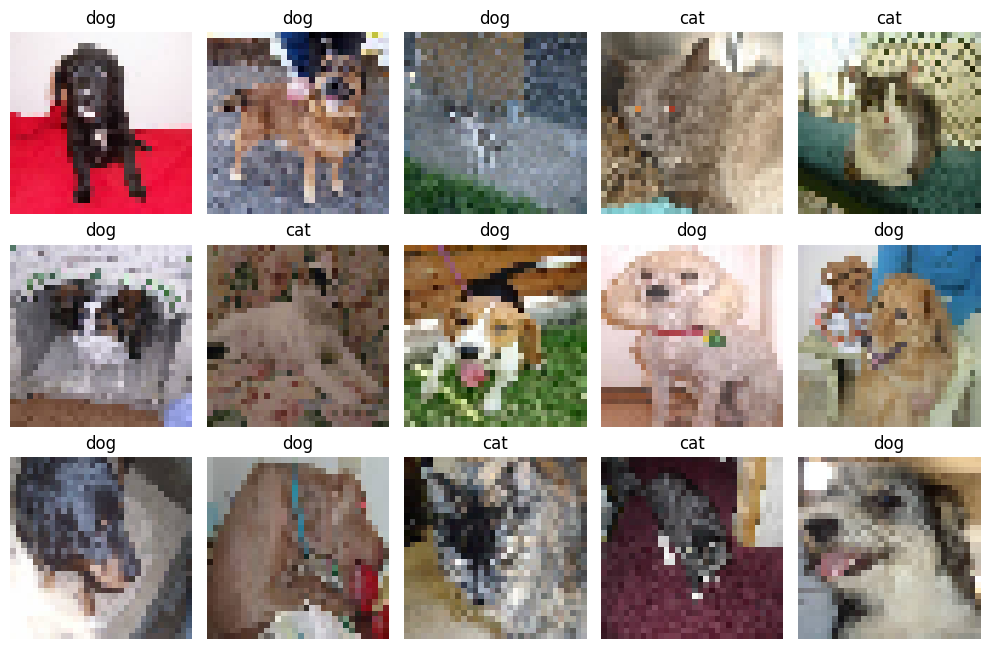

In [6]:
def plot_images(X, y_names, n_cols=5, indices=None):
    if indices is None:
        indices = np.random.choice(len(X), size=min(15, len(X)), replace=False)
    n_rows = (len(indices) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    for i, idx in enumerate(indices):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[idx])
        plt.title(y_names[idx])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_images(X_train, y_train_names)

#### MiniEDA

Comprobamos forma, tipo de dato, rango de los píxeles y equilibrio de clases (aquí sí importa el equilibrio porque, al ser sólo dos clases, un desbalanceo fuerte afectaría a la interpretación del accuracy).

Shape X_train: (4000, 32, 32, 3) - dtype: uint8
Rango de píxeles: [ 0 , 255 ]
Valores nulos: 0


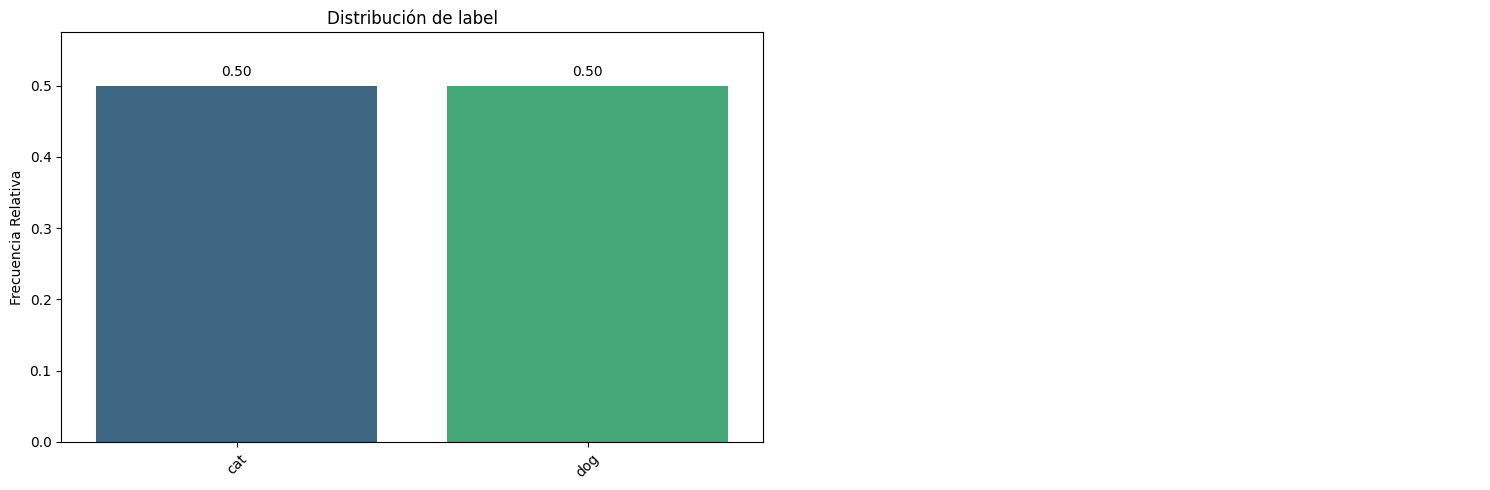

In [7]:
print("Shape X_train:", X_train.shape, "- dtype:", X_train.dtype)
print("Rango de píxeles: [", X_train.min(), ",", X_train.max(), "]")
print("Valores nulos:", np.isnan(X_train.astype(float)).sum())

bt.pinta_distribucion_categoricas(pd.DataFrame({"label": y_train_names}), ["label"], True, True)

Clases equilibradas (2000 y 2000), así que "accuracy" nos va a servir bien como métrica.

#### Transformación de features

Igual que en el workout: escalamos los píxeles a [0,1] dividiendo por 255. Además codificamos la etiqueta de texto (`cat`/`dog`) a numérica (0/1) para poder usarla con una salida `sigmoid` (clasificación binaria).

In [8]:
label_to_int = {"cat": 0, "dog": 1}

X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

y_train_enc = np.array([label_to_int[label] for label in y_train_names])
y_test_enc = np.array([label_to_int[label] for label in y_test_names])

X_train_norm.shape, y_train_enc.shape

((4000, 32, 32, 3), (4000,))

#### Construcción del modelo

Montamos una CNN con dos juegos Convolucional-Pooling (como mínimo pide el enunciado), con Dropout tras cada uno para regularizar, y una cabeza densa final. Como es un problema binario (cat=0, dog=1), la salida es una única neurona con activación `sigmoid`.

* 1º bloque: Conv2D(32, 3x3) + MaxPool(2x2) + Dropout(0.25)
* 2º bloque: Conv2D(64, 3x3) + MaxPool(2x2) + Dropout(0.25)
* Flatten + Dense(128, relu) + Dropout(0.5) + Dense(1, sigmoid)

In [9]:
def build_model():
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same",
                      activation="relu", input_shape=(32, 32, 3)))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model


model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,937 (2.07 MB)

 Trainable params: 543,937 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 3: Entrenamiento

Entrenamos reservando un 20% de train para validación, con un callback de `EarlyStopping` que vigila el `val_loss` con paciencia 5 y recupera los mejores pesos encontrados (así evitamos quedarnos con el modelo del último epoch si ha empeorado).

In [10]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

batch_size = 32
epochs = 30
validation_split = 0.2

history = model.fit(
    X_train_norm, y_train_enc,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=[early_stop],
)

Epoch 1/30


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5122 - loss: 0.7016 - val_accuracy: 0.5900 - val_loss: 0.6840
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6278 - loss: 0.6551 - val_accuracy: 0.6425 - val_loss: 0.6372
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6531 - loss: 0.6191 - val_accuracy: 0.6500 - val_loss: 0.6153
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6872 - loss: 0.5953 - val_accuracy: 0.6775 - val_loss: 0.6000
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7100 - loss: 0.5573 - val_accuracy: 0.7025 - val_loss: 0.5884
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7075 - loss: 0.5640 - val_accuracy: 0.6837 - val_loss: 0.5954
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7341 - loss: 0.5271 - val_accuracy: 0.7038 - val_loss: 0.5752
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7412 - loss: 0.5189 - val_accuracy: 0.675

Veamos el historial de entrenamiento:

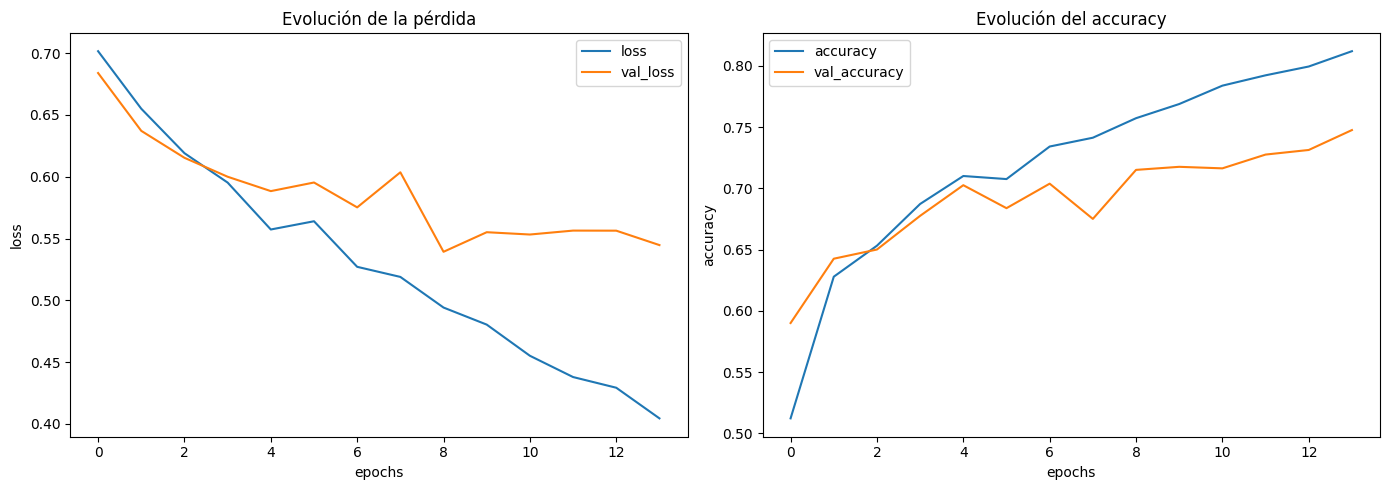

In [11]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].set_title("Evolución de la pérdida")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Evolución del accuracy")

plt.tight_layout()
plt.show()

### Ejercicio 4: Evaluación del modelo

Evaluamos contra el conjunto de test (que aunque su función real sea de "banco de candidatas a CAPTCHA", también trae la etiqueta en el nombre de fichero, así que podemos usarlo para medir el rendimiento real del modelo).

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7270 - loss: 0.5424
Test loss: 0.5424 - Test accuracy: 0.7270
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

         cat       0.73      0.72      0.73       500
         dog       0.72      0.73      0.73       500

    accuracy                           0.73      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.73      0.73      0.73      1000



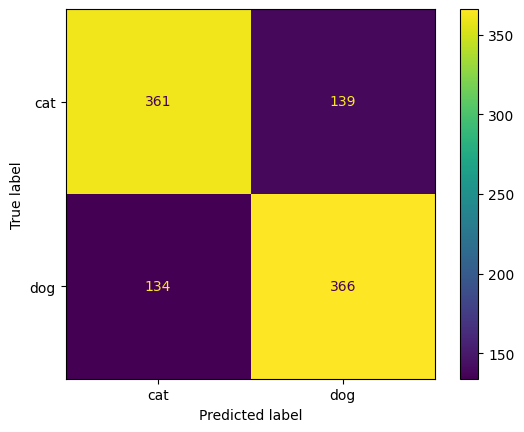

In [12]:
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_enc)
print(f"Test loss: {test_loss:.4f} - Test accuracy: {test_accuracy:.4f}")

y_pred_prob = model.predict(X_test_norm).ravel()  # probabilidad de ser "dog"
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test_enc, y_pred, target_names=CLASS_NAMES))
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred, display_labels=CLASS_NAMES)
plt.show()

### Ejercicio 5: Selección de las imágenes más "difíciles"

Buscamos, dentro de las imágenes mal clasificadas de cada clase, el 10% con mayor confianza en la clase **incorrecta** (es decir, las que más "engañan" al modelo). Éstas serían las candidatas ideales para el nuevo CAPTCHA, porque son las que un sistema anti-CAPTCHA "confundiría" con más seguridad.

* Si la imagen es de un perro (`dog`, clase 1) y se predijo `cat`, su confianza en la clase errónea es `1 - p(dog)`.
* Si la imagen es de un gato (`cat`, clase 0) y se predijo `dog`, su confianza en la clase errónea es `p(dog)`.

Montamos un DataFrame con toda la información de test para poder filtrar y ordenar cómodamente.

In [13]:
def select_hardest_misclassified(y_true, y_pred_prob, top_pct=0.10):
    """
    De entre las imágenes mal clasificadas de cada clase, selecciona el top_pct
    con mayor confianza en la clase incorrecta.
    Devuelve un DataFrame ordenado con: índice, clase real, clase predicha,
    p(dog) y confianza en el error.
    """
    y_pred = (y_pred_prob > 0.5).astype(int)

    df = pd.DataFrame({
        "index": np.arange(len(y_true)),
        "true_label": y_true,
        "pred_label": y_pred,
        "p_dog": y_pred_prob,
    })
    df["wrong_confidence"] = np.where(df["true_label"] == 1, 1 - df["p_dog"], df["p_dog"])
    df_wrong = df[df["true_label"] != df["pred_label"]]

    selected = []
    for true_class in [0, 1]:
        subset = df_wrong[df_wrong["true_label"] == true_class].sort_values(
            "wrong_confidence", ascending=False
        )
        n_selected = int(np.ceil(len(subset) * top_pct))
        selected.append(subset.head(n_selected))

    return pd.concat(selected).sort_values("wrong_confidence", ascending=False)


hardest_df = select_hardest_misclassified(y_test_enc, y_pred_prob, top_pct=0.10)
print(f"Imágenes mal clasificadas en total: {(y_pred != y_test_enc).sum()} de {len(y_test_enc)}")
print(f"Imágenes seleccionadas como más 'difíciles': {len(hardest_df)}")
hardest_df.head(10)

Imágenes mal clasificadas en total: 273 de 1000
Imágenes seleccionadas como más 'difíciles': 28


,index,true_label,pred_label,p_dog,wrong_confidence
337,337,0,1,0.998768,0.998768
680,680,1,0,0.004477,0.995523
229,229,0,1,0.977490,0.977490
284,284,0,1,0.976110,0.976110
13,13,0,1,0.957490,0.957490
662,662,1,0,0.046515,0.953485
851,851,1,0,0.052202,0.947798
537,537,1,0,0.071236,0.928764
863,863,1,0,0.078103,0.921897
893,893,1,0,0.089973,0.910027


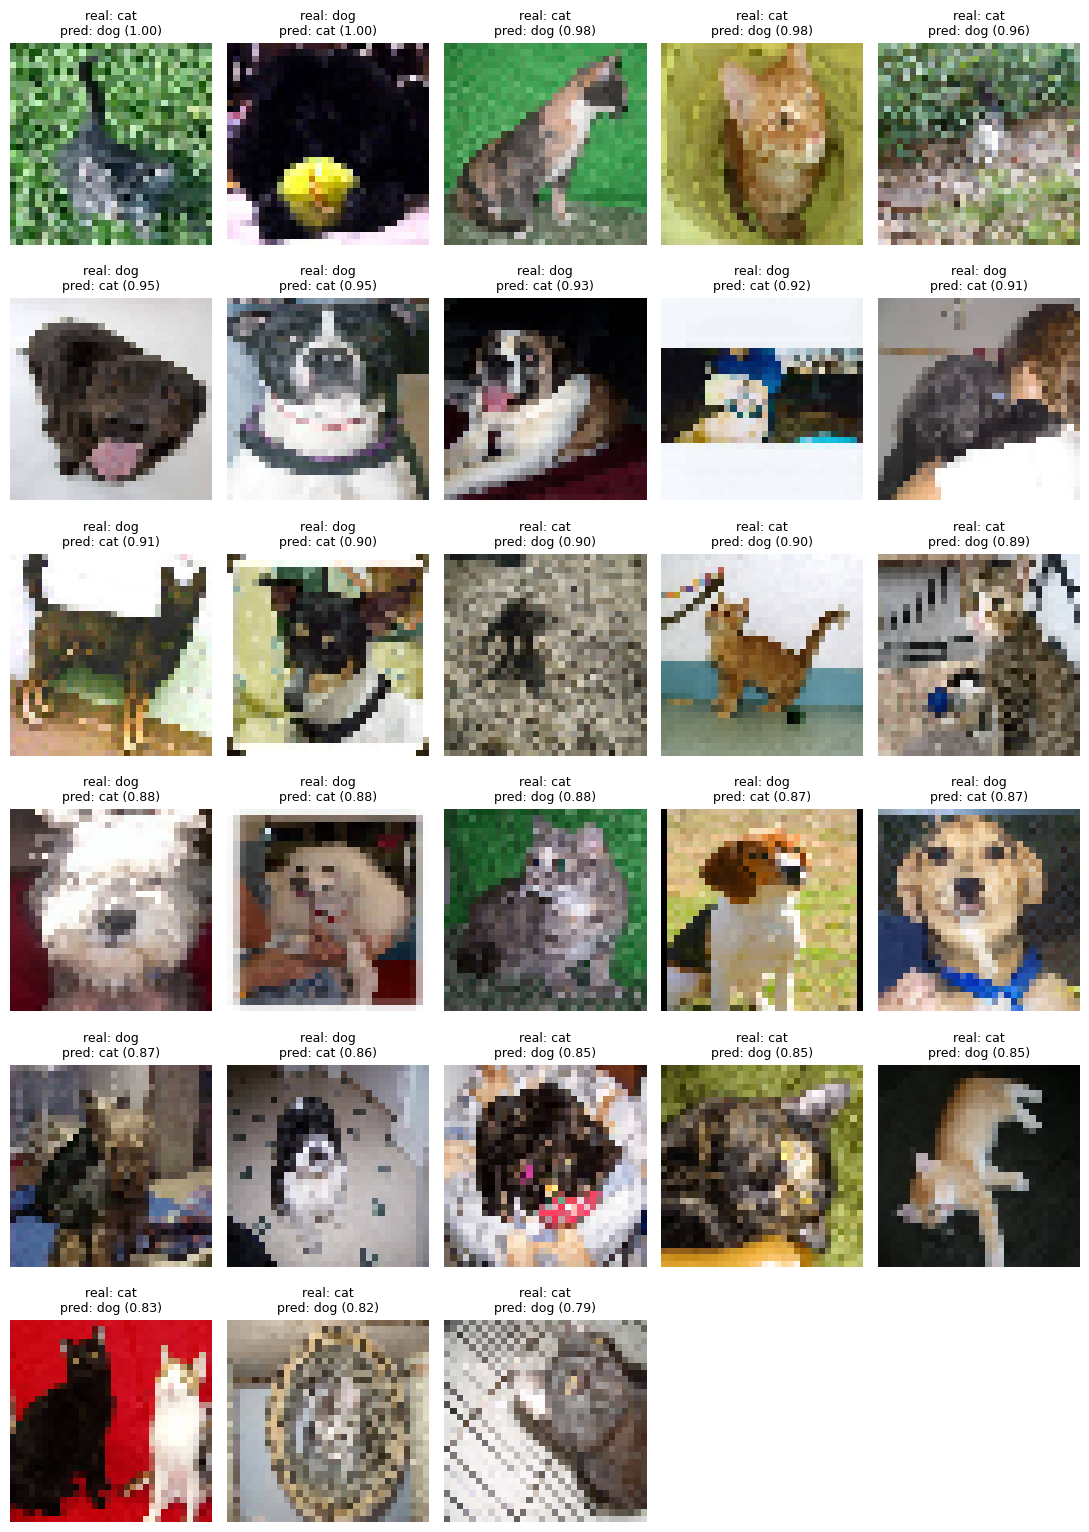

In [14]:
def plot_hardest(hardest_df, X, n_cols=5):
    n_rows = (len(hardest_df) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2.2, n_rows * 2.6))
    for i, (_, row) in enumerate(hardest_df.iterrows()):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[int(row["index"])])
        real = CLASS_NAMES[int(row["true_label"])]
        pred = CLASS_NAMES[int(row["pred_label"])]
        plt.title(f"real: {real}\npred: {pred} ({row['wrong_confidence']:.2f})", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_hardest(hardest_df, X_test)

### Extra: Repetimos con Image Augmentation

Vamos a repetir el entrenamiento (paso 3), la evaluación (paso 4) y la selección de imágenes difíciles (paso 5), pero esta vez generando variaciones sintéticas de las imágenes de train (rotaciones, desplazamientos, zoom y flips horizontales) para que el modelo generalice mejor y sea más "robusto" (justo lo contrario de lo que queremos vender a nuestro cliente, pero es un buen ejercicio para comparar :-)).

Reutilizamos la misma arquitectura (`build_model`) para que la comparación sea justa, entrenando un modelo nuevo desde cero.

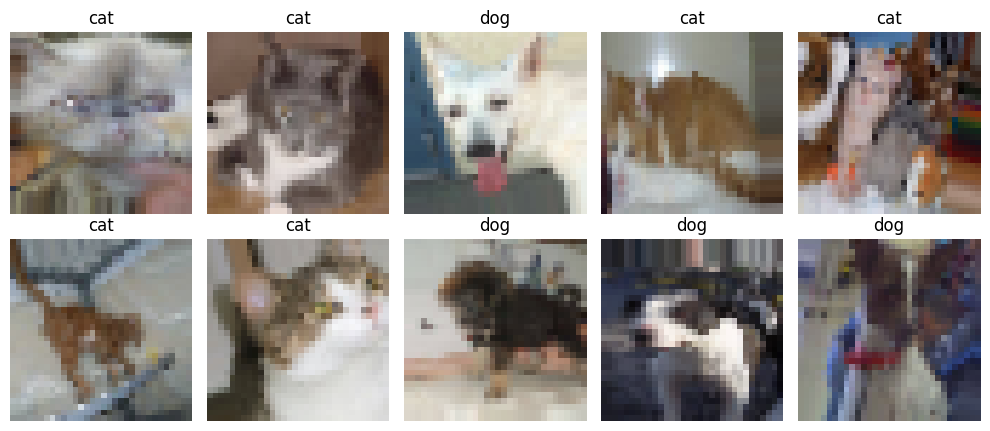

In [15]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2,
)

train_generator = datagen.flow(
    X_train_norm, y_train_enc, batch_size=batch_size, subset="training", seed=42
)
val_generator = datagen.flow(
    X_train_norm, y_train_enc, batch_size=batch_size, subset="validation", seed=42
)

# Un vistazo a cómo quedan algunas imágenes aumentadas
X_aug_batch, y_aug_batch = next(train_generator)
plot_images(X_aug_batch, [CLASS_NAMES[i] for i in y_aug_batch.astype(int)], indices=range(min(10, len(X_aug_batch))))

In [16]:
model_aug = build_model()

early_stop_aug = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_aug = model_aug.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop_aug],
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5034 - loss: 0.6980 - val_accuracy: 0.5238 - val_loss: 0.6913
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5466 - loss: 0.6889 - val_accuracy: 0.6313 - val_loss: 0.6745
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5775 - loss: 0.6710 - val_accuracy: 0.6338 - val_loss: 0.6412
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6350 - loss: 0.6479 - val_accuracy: 0.6575 - val_loss: 0.6304
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6400 - loss: 0.6381 - val_accuracy: 0.6938 - val_loss: 0.6027
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6559 - loss: 0.6183 - val_accuracy: 0.7163 - val_loss: 0.5815
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6731 - loss: 0.6048 - val_accuracy: 0.6925 - val_loss: 0.5752
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6731 - loss: 0.6031 - val_accu

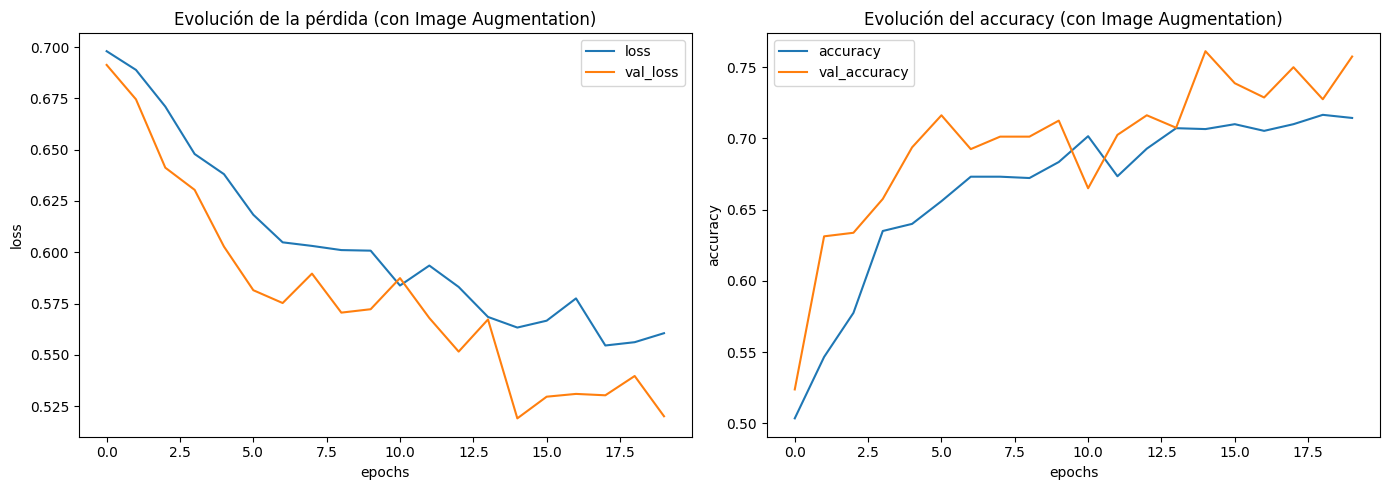

In [17]:
history_aug_df = pd.DataFrame(history_aug.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
history_aug_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].set_title("Evolución de la pérdida (con Image Augmentation)")

history_aug_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Evolución del accuracy (con Image Augmentation)")

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7090 - loss: 0.5577
Test loss: 0.5577 - Test accuracy: 0.7090
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

         cat       0.80      0.56      0.66       500
         dog       0.66      0.86      0.75       500

    accuracy                           0.71      1000
   macro avg       0.73      0.71      0.70      1000
weighted avg       0.73      0.71      0.70      1000



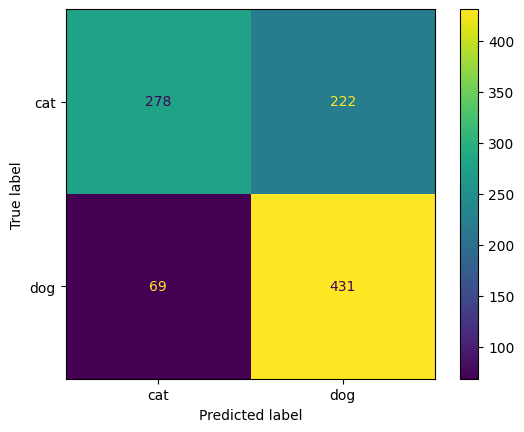

In [18]:
test_loss_aug, test_accuracy_aug = model_aug.evaluate(X_test_norm, y_test_enc)
print(f"Test loss: {test_loss_aug:.4f} - Test accuracy: {test_accuracy_aug:.4f}")

y_pred_prob_aug = model_aug.predict(X_test_norm).ravel()
y_pred_aug = (y_pred_prob_aug > 0.5).astype(int)

print(classification_report(y_test_enc, y_pred_aug, target_names=CLASS_NAMES))
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred_aug, display_labels=CLASS_NAMES)
plt.show()

Imágenes mal clasificadas en total: 291 de 1000
Imágenes seleccionadas como más 'difíciles': 30


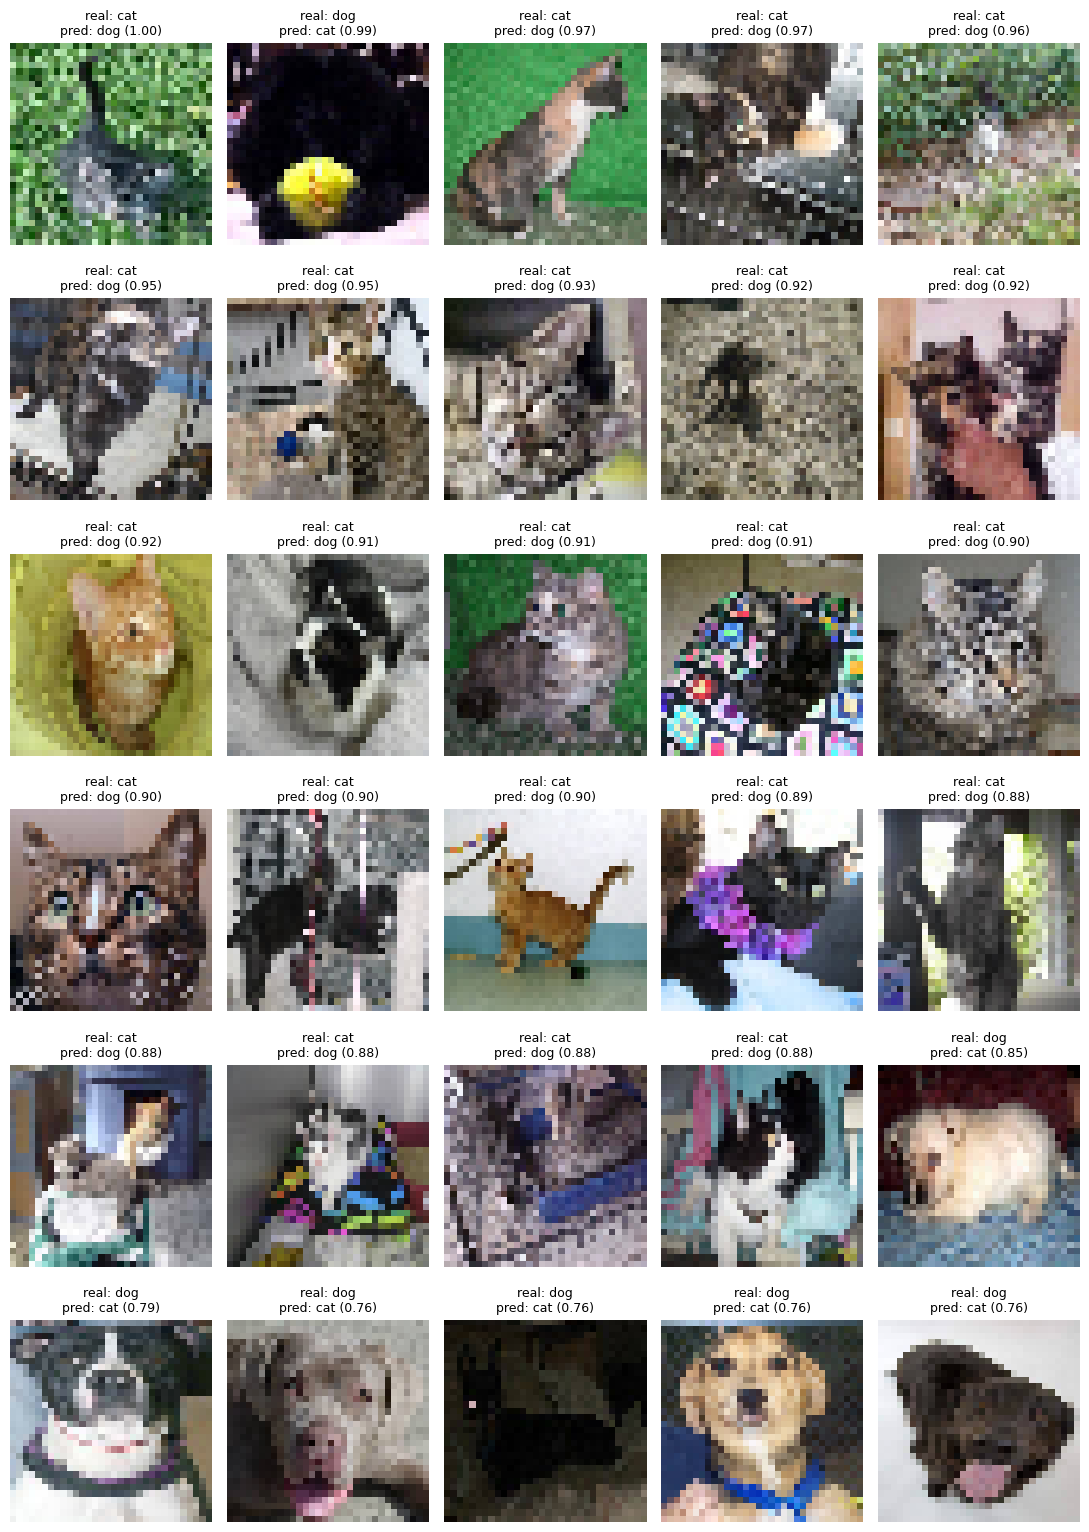

In [19]:
hardest_df_aug = select_hardest_misclassified(y_test_enc, y_pred_prob_aug, top_pct=0.10)
print(f"Imágenes mal clasificadas en total: {(y_pred_aug != y_test_enc).sum()} de {len(y_test_enc)}")
print(f"Imágenes seleccionadas como más 'difíciles': {len(hardest_df_aug)}")

plot_hardest(hardest_df_aug, X_test)

In [20]:
print(f"Accuracy en test SIN augmentation: {test_accuracy:.4f}")
print(f"Accuracy en test CON augmentation: {test_accuracy_aug:.4f}")

Accuracy en test SIN augmentation: 0.7270
Accuracy en test CON augmentation: 0.7090
